In [13]:
#import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder   

In [14]:
#load the dataset
df = pd.read_csv("student_mental_health_burnout.csv")   
df.head()


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [16]:
df.shape

(150000, 20)

In [17]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [18]:
#remove Unnecessary Columns
df.drop(['student_id'], axis=1, inplace=True)

In [33]:
#handle Missing Values
# Fill numerical missing values with mean
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
categorical_missing_cols = df.select_dtypes(include=['object']).columns

for col in categorical_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [34]:
# Detect and remove outliers using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

In [21]:
#encode categorical variables
le = LabelEncoder()
categorical_cols = [
    'gender',
    'course',
    'year',
    'stress_level',
    'sleep_quality',
    'internet_quality',
    'burnout_level'
]

# Apply Label Encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [22]:
#Separate Features and Target Variable
X = df.drop('burnout_level', axis=1)
y = df['burnout_level']

In [25]:
#feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)    
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (120000, 18)
Testing Data Shape: (30000, 18)


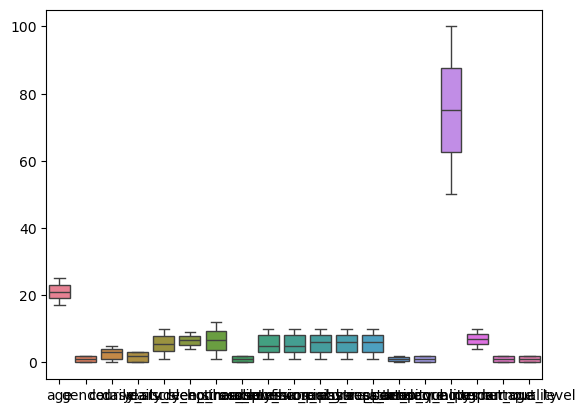

In [29]:
#outliers
sns.boxplot(data=df)
plt.show()

In [35]:
#Perform Logistic Classification
model = LogisticRegression()
model.fit(X_train, y_train)
#Make Predictions
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.33026666666666665

Confusion Matrix:

[[2057 4589 3375]
 [2143 4517 3364]
 [2091 4530 3334]]

Classification Report:

              precision    recall  f1-score   support

           0       0.33      0.21      0.25     10021
           1       0.33      0.45      0.38     10024
           2       0.33      0.33      0.33      9955

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.32     30000
weighted avg       0.33      0.33      0.32     30000

